# Chapter 5 Case Study — Data Visualization & Storytelling
## Global Superstore Sales Analysis
**Student Name:** shahil kumar jha 
---

## Section 1 — Introduction & Dataset Overview

### Dataset Description
The **Global Superstore Sales** dataset contains transactional retail data from a fictional global superstore. It covers orders placed across multiple countries, product categories, and customer segments.

**Source:** [Kaggle — Global Superstore](https://www.kaggle.com/datasets/apoorvaappz/global-super-store-dataset)  
**File used:** `Global_Superstore2.csv`

### Key Columns
| Column | Type | Description |
|---|---|---|
| Order Date | Date | When the order was placed |
| Ship Date | Date | When the order was shipped |
| Category | Categorical | Furniture, Office Supplies, Technology |
| Sub-Category | Categorical | e.g. Chairs, Phones, Binders |
| Sales | Numerical | Revenue from the order |
| Profit | Numerical | Profit from the order |
| Quantity | Numerical | Units ordered |
| Discount | Numerical | Discount applied (0–1) |
| Region | Categorical | Geographic region |
| Country | Categorical | Country of the customer |
| Segment | Categorical | Consumer, Corporate, Home Office |


In [32]:
#imports
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import plotly.express as px
import plotly.io as pio

In [33]:
df=pd.read_csv('Global_Superstore2.csv',encoding='latin1')
print(F"Shape : {df.shape}")
df.head()

Shape : (51290, 24)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
0,32298,CA-2012-124891,31-07-2012,31-07-2012,Same Day,RH-19495,Rick Hansen,Consumer,New York City,New York,...,TEC-AC-10003033,Technology,Accessories,Plantronics CS510 - Over-the-Head monaural Wir...,2309.650,7,0.0,762.1845,933.57,Critical
1,26341,IN-2013-77878,05-02-2013,07-02-2013,Second Class,JR-16210,Justin Ritter,Corporate,Wollongong,New South Wales,...,FUR-CH-10003950,Furniture,Chairs,"Novimex Executive Leather Armchair, Black",3709.395,9,0.1,-288.7650,923.63,Critical
2,25330,IN-2013-71249,17-10-2013,18-10-2013,First Class,CR-12730,Craig Reiter,Consumer,Brisbane,Queensland,...,TEC-PH-10004664,Technology,Phones,"Nokia Smart Phone, with Caller ID",5175.171,9,0.1,919.9710,915.49,Medium
3,13524,ES-2013-1579342,28-01-2013,30-01-2013,First Class,KM-16375,Katherine Murray,Home Office,Berlin,Berlin,...,TEC-PH-10004583,Technology,Phones,"Motorola Smart Phone, Cordless",2892.510,5,0.1,-96.5400,910.16,Medium
4,47221,SG-2013-4320,05-11-2013,06-11-2013,Same Day,RH-9495,Rick Hansen,Consumer,Dakar,Dakar,...,TEC-SHA-10000501,Technology,Copiers,"Sharp Wireless Fax, High-Speed",2832.960,8,0.0,311.5200,903.04,Critical


In [34]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          51290 non-null  int64  
 1   Order ID        51290 non-null  str    
 2   Order Date      51290 non-null  str    
 3   Ship Date       51290 non-null  str    
 4   Ship Mode       51290 non-null  str    
 5   Customer ID     51290 non-null  str    
 6   Customer Name   51290 non-null  str    
 7   Segment         51290 non-null  str    
 8   City            51290 non-null  str    
 9   State           51290 non-null  str    
 10  Country         51290 non-null  str    
 11  Postal Code     9994 non-null   float64
 12  Market          51290 non-null  str    
 13  Region          51290 non-null  str    
 14  Product ID      51290 non-null  str    
 15  Category        51290 non-null  str    
 16  Sub-Category    51290 non-null  str    
 17  Product Name    51290 non-null  str    
 1

In [35]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit,Shipping Cost
count,51290.00000,9994.000000,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000
mean,25645.50000,55190.379428,246.490581,3.476545,0.142908,28.610982,26.375915
std,14806.29199,32063.693350,487.565361,2.278766,0.212280,174.340972,57.296804
min,1.00000,1040.000000,0.444000,1.000000,0.000000,-6599.978000,0.000000
25%,12823.25000,23223.000000,30.758625,2.000000,0.000000,0.000000,2.610000
50%,25645.50000,56430.500000,85.053000,3.000000,0.000000,9.240000,7.790000
75%,38467.75000,90008.000000,251.053200,5.000000,0.200000,36.810000,24.450000
max,51290.00000,99301.000000,22638.480000,14.000000,0.850000,8399.976000,933.570000


In [36]:
#missing value 
df.isnull().sum()

Row ID                0
Order ID              0
Order Date            0
Ship Date             0
Ship Mode             0
Customer ID           0
Customer Name         0
Segment               0
City                  0
State                 0
Country               0
Postal Code       41296
Market                0
Region                0
Product ID            0
Category              0
Sub-Category          0
Product Name          0
Sales                 0
Quantity              0
Discount              0
Profit                0
Shipping Cost         0
Order Priority        0
dtype: int64

In [37]:
#handling missing value 
df.drop(columns=['Postal Code'],inplace=True)
#Postal code often doesn't help in analysis
#Too many missing values
df.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
City              0
State             0
Country           0
Market            0
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Quantity          0
Discount          0
Profit            0
Shipping Cost     0
Order Priority    0
dtype: int64

### Chart 1 — Line Chart: Monthly Sales & Profit Over Time

**What we are showing:** Total sales and profit aggregated by month across the full dataset timeline.  
**Why:** A line chart is the correct choice for showing a continuous numerical variable over ordered time intervals.


C:\Users\shahi\AppData\Local\Temp\ipykernel_4236\4240713055.py:1: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Order Date']=pd.to_datetime(df['Order Date'])


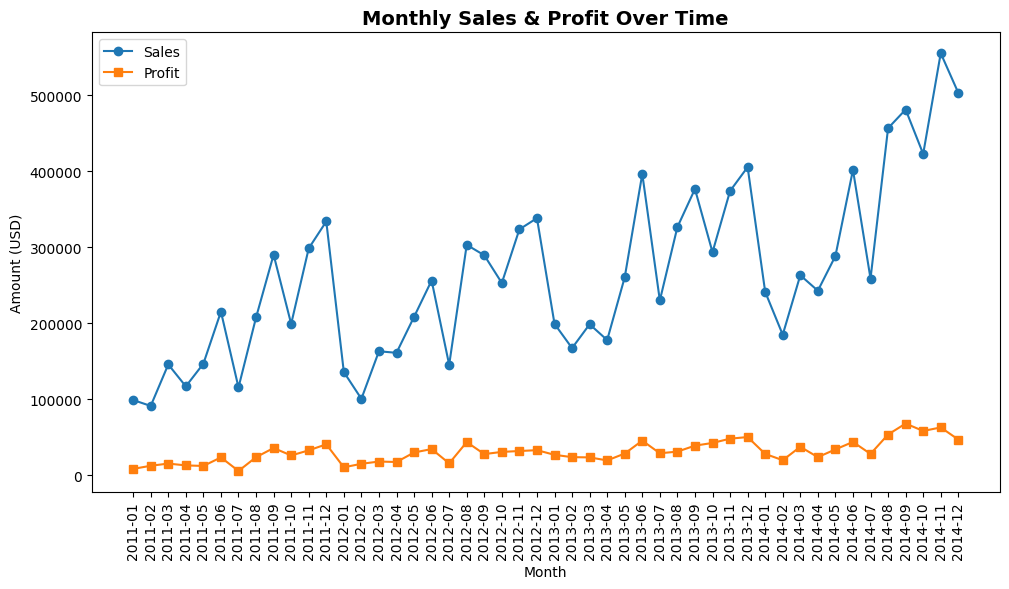

In [38]:
df['Order Date']=pd.to_datetime(df['Order Date'])
df['YearMonth']=df['Order Date'].dt.to_period('M')
monthly = df.groupby('YearMonth')[['Sales', 'Profit']].sum().reset_index()
monthly['YearMonth_str']=monthly['YearMonth'].astype(str)
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(monthly['YearMonth_str'], monthly['Sales'], label='Sales', marker='o')
ax.plot(monthly['YearMonth_str'], monthly['Profit'], label='Profit', marker='s')

ax.set_title('Monthly Sales & Profit Over Time', fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
plt.xticks(rotation=90)
plt.tight_layout()
ax.set_ylabel('Amount (USD)')
ax.legend()
plt.savefig('chart1_line_monthly_sales.png', dpi=150)
plt.show()


**Insight — Chart 1:**  
- **Observation:** Sales show a clear seasonal pattern, spiking toward the end of each calendar year (Q4), with profit following a similar but more volatile trajectory.  
- **Explanation:** Q4 includes major retail events (Black Friday, holiday shopping), which drive higher purchase volumes globally.  
- **Implication:** The business should ensure adequate inventory and staffing for Q4 peaks. Profit dips mid-year may indicate discount-heavy promotional periods that compress margins.


### Chart 2 — Bar Chart: Total Sales by Region

**What we are showing:** Total revenue contributed by each geographic region.  
**Why:** A bar chart is ideal for comparing a single numerical measure across discrete categories.


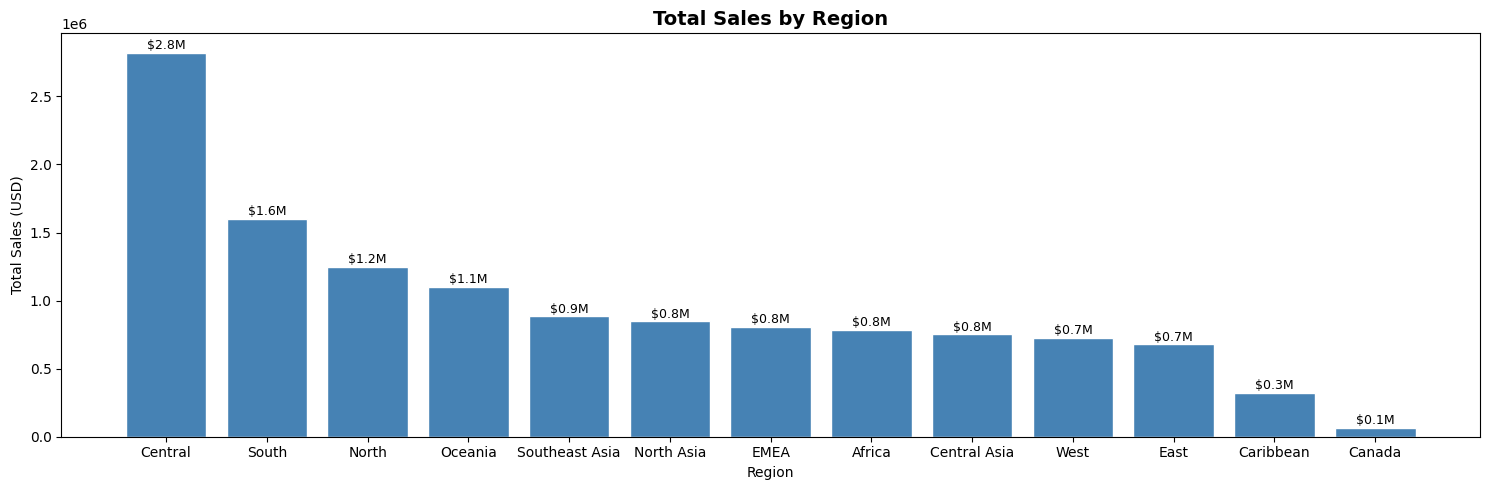

In [39]:
region_sales=df.groupby('Region')['Sales'].sum().sort_values(ascending=False).reset_index()
fig, ax = plt.subplots(figsize=(15, 5))
bars = ax.bar(region_sales['Region'], region_sales['Sales'], color='steelblue', edgecolor='white')
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, height + 5000,
            f'${height/1e6:.1f}M', ha='center', va='bottom', fontsize=9)

ax.set_title('Total Sales by Region', fontsize=14, fontweight='bold')
ax.set_xlabel('Region')
ax.set_ylabel('Total Sales (USD)')

plt.tight_layout()
plt.savefig('chart2_bar_region_sales.png', dpi=150)
plt.show()


**Insight — Chart 2:**  
- **Observation:** The top regions account for a disproportionate share of total sales, with a significant gap between the leading region and the lowest performers.  
- **Explanation:** Geographic concentration reflects where the superstore's customer base and distribution network is strongest.  
- **Implication:** Lower-performing regions may represent untapped growth opportunities, or alternatively, markets where the cost of operations exceeds returns — worth investigating before expanding.


### Chart 3 — Histogram: Distribution of Order Profit

**What we are showing:** The frequency distribution of profit values across all individual orders.  
**Why:** A histogram reveals the shape, spread, and skew of a single numerical variable.


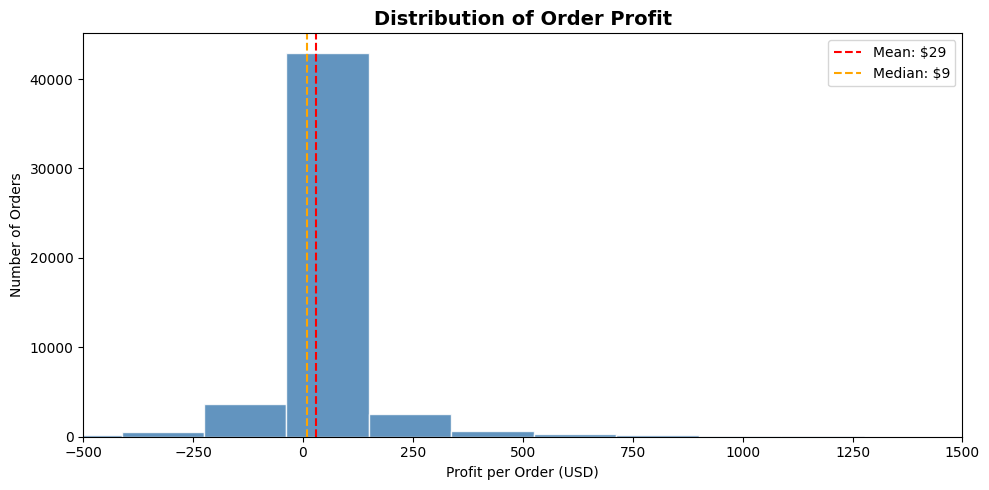

In [40]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df['Profit'], bins=80, color='steelblue', edgecolor='white', alpha=0.85)
ax.axvline(df['Profit'].mean(),   color='red',    linestyle='--', linewidth=1.5, label=f"Mean: ${df['Profit'].mean():.0f}")
ax.axvline(df['Profit'].median(), color='orange', linestyle='--', linewidth=1.5, label=f"Median: ${df['Profit'].median():.0f}")

ax.set_title('Distribution of Order Profit', fontsize=14, fontweight='bold')
ax.set_xlabel('Profit per Order (USD)')
ax.set_ylabel('Number of Orders')
ax.set_xlim(-500, 1500)   # zoom in; extreme outliers exist but are rare
ax.legend()

plt.tight_layout()
plt.savefig('chart3_histogram_profit.png', dpi=150)
plt.show()

**Insight — Chart 3:**  
- **Observation:** The distribution is right-skewed, with the majority of orders yielding modest profits. A non-trivial tail of loss-making orders (negative profit) exists.  
- **Explanation:** The mean being higher than the median indicates that a small number of high-profit orders pull the average up, while many orders break even or generate small losses — often due to heavy discounting.  
- **Implication:** Discounting strategy needs review. Loss-making orders drag down overall profitability and may be subsidising customers who would purchase anyway.


### Chart 4 — Scatter Plot: Discount vs. Profit

**What we are showing:** The relationship between the discount applied to an order and the resulting profit.  
**Why:** A scatter plot is the standard choice for visualising the relationship between two continuous numerical variables.


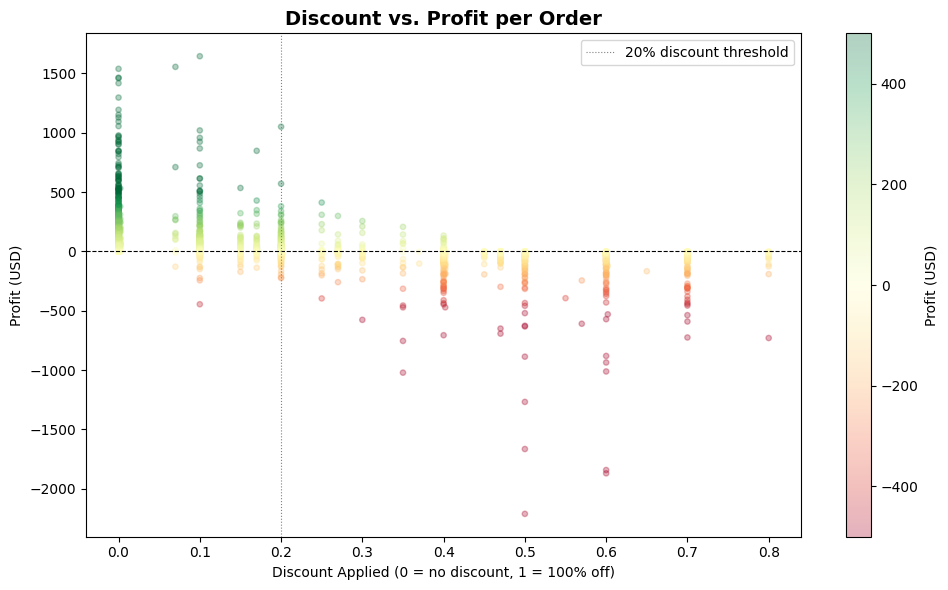

In [41]:
sample = df.sample(min(5000, len(df)), random_state=42)

fig, ax = plt.subplots(figsize=(10, 6))

scatter = ax.scatter(
    sample['Discount'], sample['Profit'],
    alpha=0.3, s=15,
    c=sample['Profit'], cmap='RdYlGn', vmin=-500, vmax=500
)

ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.axvline(0.2, color='grey', linewidth=0.8, linestyle=':', label='20% discount threshold')

plt.colorbar(scatter, ax=ax, label='Profit (USD)')
ax.set_title('Discount vs. Profit per Order', fontsize=14, fontweight='bold')
ax.set_xlabel('Discount Applied (0 = no discount, 1 = 100% off)')
ax.set_ylabel('Profit (USD)')
ax.legend()

plt.tight_layout()
plt.savefig('chart4_scatter_discount_profit.png', dpi=150)
plt.show()

**Insight — Chart 4:**  
- **Observation:** There is a clear negative relationship between discount level and profit. Orders with discounts above ~20% are overwhelmingly loss-making (red points below the zero line).  
- **Explanation:** Deep discounts erode the revenue base faster than cost savings can compensate, turning profitable orders into losses.  
- **Implication:** The business should set a hard cap on discounts (around 20%) and require manager approval for higher discounts. This single change could dramatically improve overall profit margins.


### Chart 5 — Subplot Grid: Sales & Profit by Category and Segment

**What we are showing:** A 2×2 grid comparing sales and profit across product categories and customer segments.  
**Why:** A subplot grid allows multiple related comparisons in one figure, making it easy to draw cross-dimensional conclusions.


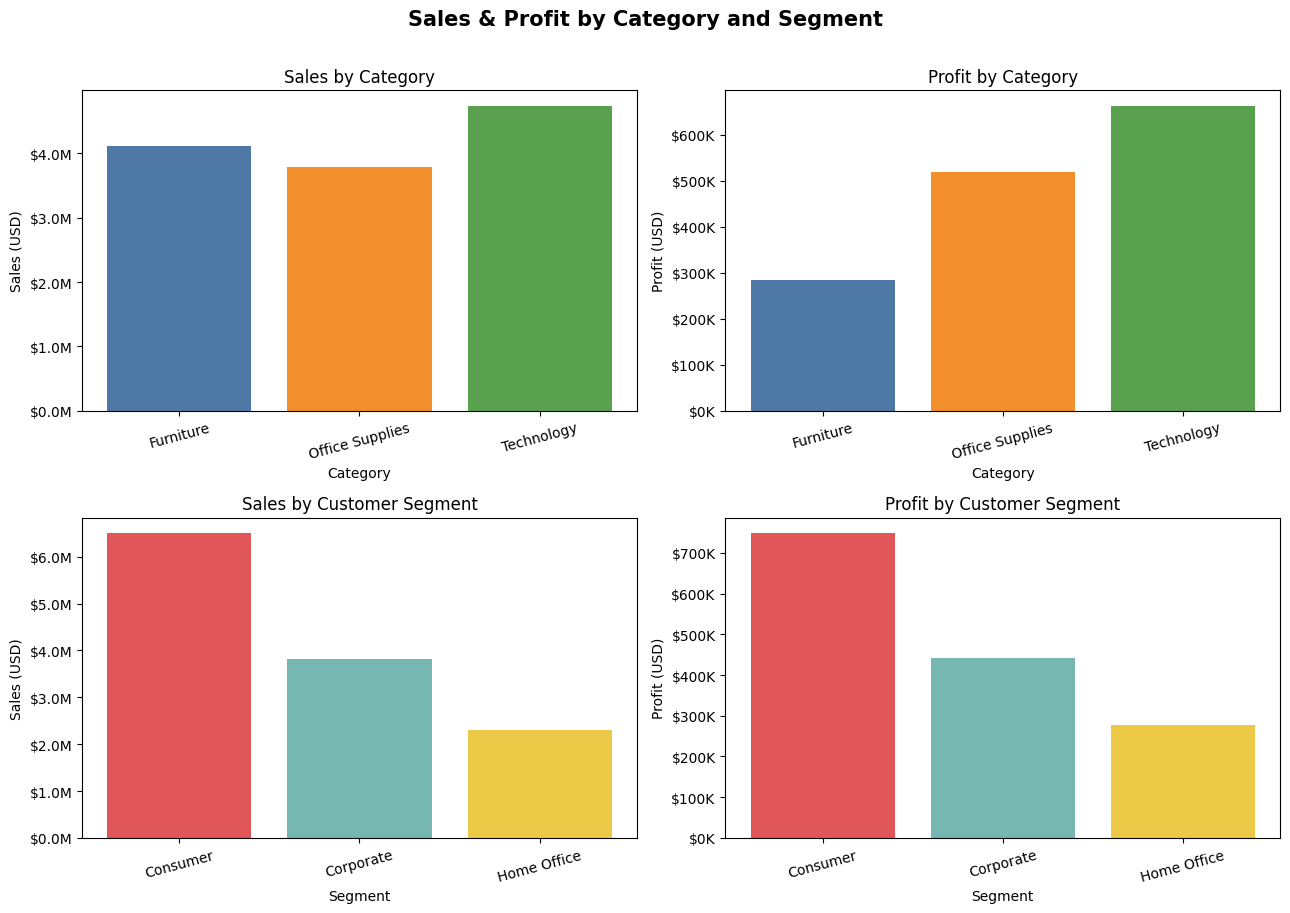

In [42]:
cat_sales   = df.groupby('Category')['Sales'].sum()
cat_profit  = df.groupby('Category')['Profit'].sum()
seg_sales   = df.groupby('Segment')['Sales'].sum()
seg_profit  = df.groupby('Segment')['Profit'].sum()

colors_cat = ['#4e79a7', '#f28e2b', '#59a14f']
colors_seg = ['#e15759', '#76b7b2', '#edc948']

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle('Sales & Profit by Category and Segment', fontsize=15, fontweight='bold', y=1.01)

# [0,0] Sales by Category
axes[0,0].bar(cat_sales.index, cat_sales.values, color=colors_cat)
axes[0,0].set_title('Sales by Category')
axes[0,0].set_xlabel('Category')
axes[0,0].set_ylabel('Sales (USD)')
axes[0,0].yaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x,_: f'${x/1e6:.1f}M'))

# [0,1] Profit by Category
axes[0,1].bar(cat_profit.index, cat_profit.values, color=colors_cat)
axes[0,1].set_title('Profit by Category')
axes[0,1].set_xlabel('Category')
axes[0,1].set_ylabel('Profit (USD)')
axes[0,1].yaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x,_: f'${x/1e3:.0f}K'))

# [1,0] Sales by Segment
axes[1,0].bar(seg_sales.index, seg_sales.values, color=colors_seg)
axes[1,0].set_title('Sales by Customer Segment')
axes[1,0].set_xlabel('Segment')
axes[1,0].set_ylabel('Sales (USD)')
axes[1,0].yaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x,_: f'${x/1e6:.1f}M'))

# [1,1] Profit by Segment
axes[1,1].bar(seg_profit.index, seg_profit.values, color=colors_seg)
axes[1,1].set_title('Profit by Customer Segment')
axes[1,1].set_xlabel('Segment')
axes[1,1].set_ylabel('Profit (USD)')
axes[1,1].yaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x,_: f'${x/1e3:.0f}K'))

for ax in axes.flat:
    ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('chart5_subplot_grid.png', dpi=150)
plt.show()


**Insight — Chart 5:**  
- **Observation:** Technology generates the highest sales *and* profit, while Furniture generates significant sales but comparatively low profit. The Consumer segment leads on both sales and profit.  
- **Explanation:** Furniture items likely carry higher shipping costs and are frequently discounted to compete, compressing margins. Technology products command premium prices with relatively lower cost bases.  
- **Implication:** Investment in Technology marketing and inventory management should be prioritised. The Furniture category warrants a pricing and discount audit.


## Section 4 — Seaborn Statistical Plots

### Chart 6 — Box Plot: Profit Distribution by Category

**What we are showing:** The spread, median, and outliers of profit for each product category.  
**Why:** Box plots reveal distributional differences across groups that bar charts hide.


C:\Users\shahi\AppData\Local\Temp\ipykernel_4236\2474226313.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


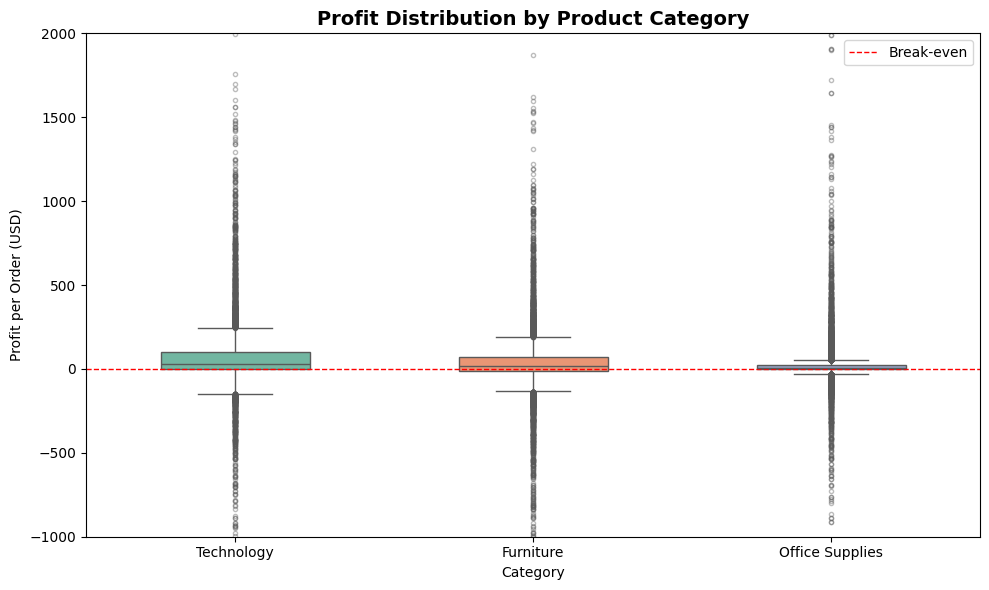

In [43]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(
    data=df, x='Category', y='Profit',
    palette='Set2', width=0.5,
    flierprops=dict(marker='o', markersize=3, alpha=0.4),
    ax=ax
)

ax.axhline(0, color='red', linestyle='--', linewidth=1, label='Break-even')
ax.set_title('Profit Distribution by Product Category', fontsize=14, fontweight='bold')
ax.set_xlabel('Category')
ax.set_ylabel('Profit per Order (USD)')
ax.set_ylim(-1000, 2000)
ax.legend()

plt.tight_layout()
plt.savefig('chart6_boxplot_profit_category.png', dpi=150)
plt.show()


**Insight — Chart 6:**  
- **Observation:** Technology has the highest median profit and the widest spread of high-value outliers. Furniture has a median profit close to zero and a notable number of loss-making outliers below the red break-even line.  
- **Explanation:** Furniture's inconsistent profitability reflects the impact of discounting and high shipping costs on large items.  
- **Implication:** The business must investigate why Furniture orders so frequently result in losses, and whether removing or re-pricing the worst-performing sub-categories (e.g. Tables) would improve overall performance.


### Chart 7 — Pair Plot: Pairwise Relationships Across Numerical Variables

**What we are showing:** Pairwise scatter plots and distributions for Sales, Profit, Quantity, and Discount.  
**Why:** A pair plot surfaces correlations and patterns across multiple numerical dimensions simultaneously.


KeyboardInterrupt: 

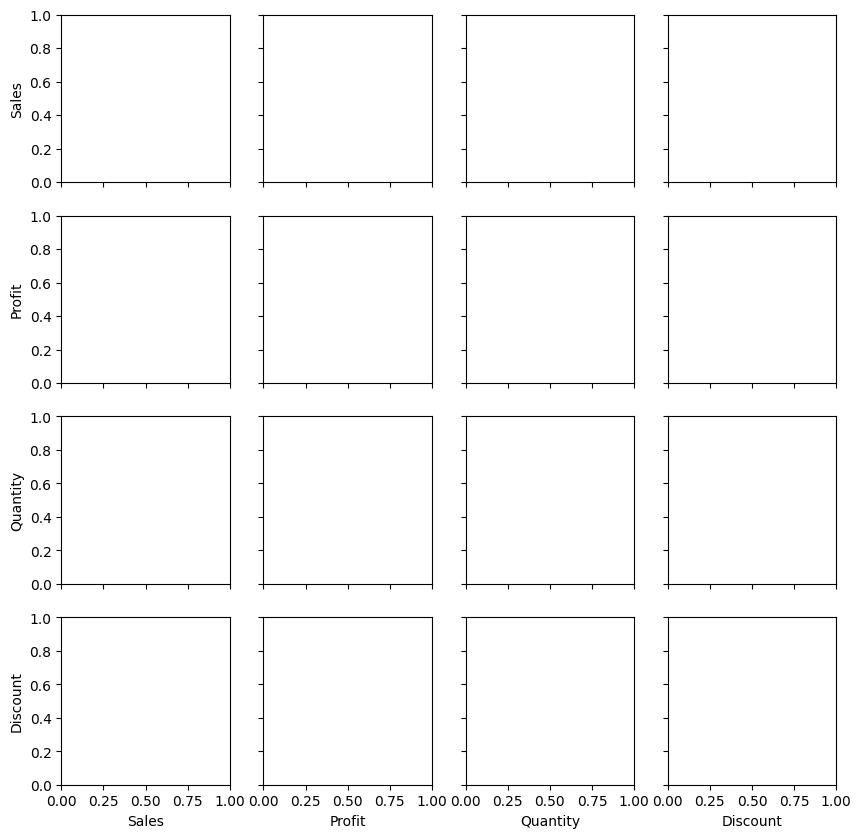

In [44]:
pair_cols = ['Sales', 'Profit', 'Quantity', 'Discount']
pair_df   = df[pair_cols + ['Category']].sample(min(2000, len(df)), random_state=42)

pair_grid = sns.pairplot(
    pair_df, vars=pair_cols,
    hue='Category', palette='Set2',
    diag_kind='kde', plot_kws={'alpha': 0.3, 's': 15}
)
pair_grid.fig.suptitle('Pairwise Relationships: Sales, Profit, Quantity, Discount',
                        fontsize=13, fontweight='bold', y=1.02)

plt.savefig('chart7_pairplot.png', dpi=150, bbox_inches='tight')
plt.show()

**Insight — Chart 7:**  
- **Observation:** The Discount vs. Profit plot (bottom-left panel) shows the clearest negative relationship. Sales and Profit show a weak positive correlation with notable spread. Quantity has little relationship with Profit.  
- **Explanation:** Revenue (Sales) does not guarantee profitability — margin erosion from discounts is the dominant driver of profit outcomes.  
- **Implication:** Quantity-based promotions ("buy more, save more") may not be harmful to profit if discounts are controlled. The real risk is percentage-based discounting.


### Chart 8 — Correlation Heatmap

**What we are showing:** A matrix of Pearson correlation coefficients between all numerical variables.  
**Why:** A heatmap makes it easy to spot strong positive or negative linear relationships at a glance.


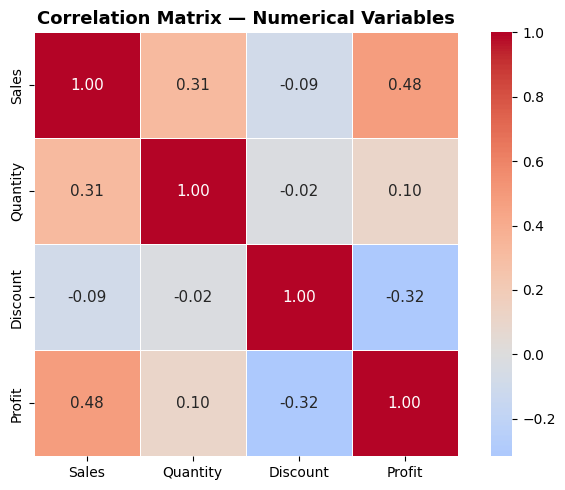

In [ ]:
num_cols = ['Sales', 'Quantity', 'Discount', 'Profit']
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(7, 5))

sns.heatmap(
    corr, annot=True, fmt='.2f',
    cmap='coolwarm', center=0,
    linewidths=0.5, linecolor='white',
    square=True, ax=ax,
    annot_kws={'size': 11}
)

ax.set_title('Correlation Matrix — Numerical Variables', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('chart8_heatmap_correlation.png', dpi=150)
plt.show()



**Insight — Chart 8:**  
- **Observation:** Discount has the strongest negative correlation with Profit (approximately −0.22). Sales and Profit show a weak positive correlation (~0.48). Quantity is nearly uncorrelated with Profit.  
- **Explanation:** These correlations confirm analytically what the scatter plot suggested: discounts destroy profit. Sales volume helps, but only if margins are protected.  
- **Implication:** Profit improvement efforts should target discount reduction first, since it is the most controllable variable with the clearest quantifiable impact.


## Section 5 — Plotly Interactive Chart

### Chart 9 — Plotly Interactive: Sales vs. Profit by Sub-Category

**What we are showing:** An interactive bubble chart where each bubble is a Sub-Category, sized by total Quantity sold, colored by Category.  
**Why:** Interactive charts allow the reader to hover for exact values and filter visually — ideal for dashboards and executive reports.

In [ ]:
sub_agg = df.groupby(['Sub-Category', 'Category']).agg(
    Sales=('Sales', 'sum'),
    Profit=('Profit', 'sum'),
    Quantity=('Quantity', 'sum')
).reset_index()

fig = px.scatter(
    sub_agg,
    x='Sales', y='Profit',
    size='Quantity', color='Category',
    hover_name='Sub-Category',
    hover_data={'Sales': ':$,.0f', 'Profit': ':$,.0f', 'Quantity': True},
    size_max=60,
    color_discrete_sequence=px.colors.qualitative.Set2,
    title='Sales vs. Profit by Sub-Category (bubble size = Quantity sold)',
    labels={'Sales': 'Total Sales (USD)', 'Profit': 'Total Profit (USD)'}
)
fig.add_hline(y=0, line_dash='dash', line_color='red', annotation_text='Break-even')

fig.update_layout(
    width=900, height=600,
    title_font_size=14,
    legend_title='Category'
)


fig.show()
fig.write_image("chart9_bubble_sales_profit.png", format='png', scale=2)  # scale=2 for higher DPI

**Insight — Chart 9:**  
- **Observation:** Hover over each bubble to see exact figures. Technology sub-categories (Copiers, Phones, Accessories) cluster in the high-sales, high-profit quadrant. Tables (Furniture) sits in negative profit despite reasonable sales volume.  
- **Explanation:** Tables carry high shipping costs and are heavily discounted to compete — a textbook example of revenue without profit.  
- **Implication:** Tables should be flagged for a product-level review: either reprice, remove from catalogue, or find cheaper fulfilment options.


## Section 6 — Key Insight Summary

After building all nine charts, the following five findings stand out as the most important and actionable:

---

**Insight 1 — Discounting is the primary driver of profit loss** *(Charts 4, 8)*  
Orders with discounts above 20% are overwhelmingly loss-making. The correlation heatmap confirms Discount is the variable most negatively correlated with Profit (≈ −0.22). A discount cap policy would have an immediate positive impact on margins.

---

**Insight 2 — Technology is the star category; Furniture underperforms** *(Charts 5, 6, 9)*  
Technology generates the highest sales and the highest profit. Furniture generates significant sales revenue but near-zero median profit, with many loss-making orders. The Tables sub-category is consistently unprofitable and should be reviewed.

---

**Insight 3 — Sales are strongly seasonal, peaking in Q4** *(Chart 1)*  
Monthly sales spike every year in Q4 (October–December). Operational planning — inventory, staffing, logistics — should be aligned to this cycle. Promotions should be managed carefully during this peak to protect margins.

---

**Insight 4 — A small number of high-value orders drive disproportionate profit** *(Charts 3, 7)*  
The profit distribution is right-skewed. The mean is significantly higher than the median, indicating that top-performing orders contribute outsized value. Retaining the customers and product types behind these orders should be a strategic priority.

---

**Insight 5 — Regional concentration presents both risk and opportunity** *(Chart 2)*  
A small number of regions account for the majority of sales. This concentration means regional disruptions (economic, logistical, political) pose significant revenue risk. Lower-performing regions may offer growth opportunities if distribution barriers can be addressed.


## Section 7 — Conclusion

### Most Important Finding
The single most important insight from this analysis is that **discounting is actively destroying profit**. The superstore is generating substantial revenue but converting it into profit poorly, primarily because a significant portion of orders are sold at discounts that exceed sustainable margins. Addressing discount discipline — particularly for Furniture and high-volume orders — represents the highest-leverage improvement available.

### Limitations
- The dataset is from a **fictional superstore**, so findings are illustrative rather than real-world validated.
- **Cost data** (cost of goods sold, shipping costs per item) is absent, making true margin analysis impossible.
- The dataset has a **fixed time window** — it is unknown whether trends observed represent long-term patterns or short-term anomalies.
- **Customer-level analysis** is not possible after removing identifiers, limiting loyalty or churn analysis.

### Further Questions
1. Which specific salespeople or customer accounts are associated with the most heavily discounted orders?
2. Can we build a predictive model to flag orders at risk of generating a loss before they are confirmed?
3. How do shipping mode choices (same day vs. standard) affect profit per order?
4. Is there a minimum order value threshold below which orders are structurally unprofitable?
